In [2]:


import os
import numpy as np
import pandas as pd
!pip install torch
import torch
import torch.nn as nn
import torch.nn.functional as F

from tqdm import tqdm
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split

!pip install torch_geometric # Install torch_geometric
from torch_geometric.data import Data, Dataset
from torch_geometric.loader import DataLoader
from torch_geometric.nn import global_mean_pool

!pip install torch-scatter
!pip install torch_cluster

from torch_cluster import radius_graph
!pip install pymatgen

from pymatgen.core import Structure

# Device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)


Using device: cpu


In [3]:
# Connect colab to drive
from google.colab import drive
drive.mount('/content/drive')

# Load dataset
df = pd.read_csv('/content/drive/MyDrive/Project/Dataset.csv')

# Drop unnecessary columns
df = df.drop(columns=['mp_material_id', 'mp_formula', 'Topological Label'])

print(df.head())
print("Total samples:", len(df))

Mounted at /content/drive
  spacegroup  spacegroup_number  number of atoms  Band Gap         a  \
0       Pm3m                221              2.0    0.0000  3.370349   
1         Cc                  9             32.0    4.8825  8.430517   
2     I4/mmm                139             18.0    1.4677  4.095118   
3       Imm2                 44              6.0    0.0000  4.409910   
4      Pm-3m                221              5.0    0.0766  4.064437   

          b          c       alpha        beta      gamma    Z  \
0  3.370349   3.370349   90.000000   90.000000  90.000000  1.0   
1  8.430517  14.075609   85.886490   85.886490  34.382176  6.4   
2  4.096245  18.221803   90.002343   90.003680  89.993481  3.6   
3  6.113668   7.554224  113.869340  106.970766  90.000000  1.0   
4  4.064437   4.064437   90.000000   90.000000  90.000000  1.0   

   electronegativity  label                      cif  
0              1.485      1     cif_files/mp-331.cif  
1              3.060      0  cif_f

In [4]:
# Extract advanced global features from CIF
def extract_features(cif_path):
    try:
        structure = Structure.from_file('/content/drive/MyDrive/Project/' + cif_path)

        elements = [site.specie for site in structure]

        masses = [el.atomic_mass for el in elements]
        enegs = [el.X for el in elements if el.X is not None]

        return pd.Series([
            structure.volume,
            structure.density,
            len(structure),
            np.mean(masses),
            np.std(masses),
            np.mean(enegs) if len(enegs) > 0 else 0,
            np.std(enegs) if len(enegs) > 0 else 0
        ])

    except:
        return pd.Series([np.nan]*7)

tqdm.pandas()

df[['volume','density','num_atoms_pymatgen',
    'mean_mass','std_mass','mean_eneg','std_eneg']] = \
    df['cif'].progress_apply(extract_features)

df = df.dropna().reset_index(drop=True)

print("Feature extraction complete.")

  0%|          | 25/7000 [00:41<36:56,  3.15it/s]/usr/local/lib/python3.12/dist-packages/pymatgen/core/structure.py:3112: UserWarning: Issues encountered while parsing CIF: 4 fractional coordinates rounded to ideal values to avoid issues with finite precision.
  struct = parser.parse_structures(primitive=primitive)[0]
  1%|          | 45/7000 [00:47<35:51,  3.23it/s]/usr/local/lib/python3.12/dist-packages/pymatgen/core/structure.py:3112: UserWarning: Issues encountered while parsing CIF: 8 fractional coordinates rounded to ideal values to avoid issues with finite precision.
  struct = parser.parse_structures(primitive=primitive)[0]
  1%|          | 85/7000 [00:59<33:23,  3.45it/s]/usr/local/lib/python3.12/dist-packages/pymatgen/core/structure.py:3112: UserWarning: Issues encountered while parsing CIF: 6 fractional coordinates rounded to ideal values to avoid issues with finite precision.
  struct = parser.parse_structures(primitive=primitive)[0]
  1%|▏         | 93/7000 [01:01<29:59,  

Feature extraction complete.


In [5]:
train_df, temp_df = train_test_split(df, test_size=0.3, stratify=df['label'], random_state=42)
val_df, test_df = train_test_split(temp_df, test_size=0.5, stratify=temp_df['label'], random_state=42)

print(len(train_df), len(val_df), len(test_df))

4900 1050 1050


In [6]:

# Graph Builder

CUTOFF = 6.0

def build_graph(row):

    structure = Structure.from_file('/content/drive/MyDrive/Project/' + row['cif'])

    # Node features
    node_features = []
    for site in structure:
        el = site.specie

        node_features.append([
            el.Z or 0,
            el.X or 0,
            float(el.atomic_mass or 0),
            el.row or 0,
            el.group or 0,
            el.atomic_radius or 0,
            int(el.is_metal),
            el.mendeleev_no or 0
        ])

    x = torch.tensor(node_features, dtype=torch.float)

    # Positions
    pos = torch.tensor(structure.cart_coords, dtype=torch.float)

    # Edges
    edge_index = radius_graph(pos, r=CUTOFF, loop=False)
    src, dst = edge_index

    distances = torch.norm(pos[src] - pos[dst], dim=1)

    # Gaussian expansion (IMPORTANT IMPROVEMENT)
    centers = torch.linspace(0, CUTOFF, 10)
    edge_attr = torch.exp(-((distances.unsqueeze(1) - centers)**2))

    # Global features
    u = torch.tensor([
        row['spacegroup_number'],
        row['number of atoms'],
        row['a'], row['b'], row['c'],
        row['alpha'], row['beta'], row['gamma'],
        row['Z'],
        row['electronegativity'],
        row['volume'],
        row['density'],
        row['mean_mass'],
        row['std_mass'],
        row['mean_eneg'],
        row['std_eneg']
    ], dtype=torch.float).unsqueeze(0)

    y = torch.tensor([row['label']], dtype=torch.long)

    return Data(x=x, edge_index=edge_index, edge_attr=edge_attr,
                pos=pos, u=u, y=y)

In [7]:
class CrystalDataset(Dataset):
    def __init__(self, df):
        self.df = df.reset_index(drop=True)

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        return build_graph(self.df.iloc[idx])


train_dataset = CrystalDataset(train_df)
val_dataset   = CrystalDataset(val_df)
test_dataset  = CrystalDataset(test_df)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_loader   = DataLoader(val_dataset, batch_size=32)
test_loader  = DataLoader(test_dataset, batch_size=32)

In [8]:
# CharlesCGCNN

from torch_geometric.nn import MessagePassing

class CGCNNConv(MessagePassing):
    def __init__(self, in_channels, edge_dim):
        super().__init__(aggr='add')

        self.lin = nn.Linear(in_channels*2 + edge_dim, in_channels)
        self.bn = nn.BatchNorm1d(in_channels)

    def forward(self, x, edge_index, edge_attr):
        return self.propagate(edge_index, x=x, edge_attr=edge_attr)

    def message(self, x_i, x_j, edge_attr):
        z = torch.cat([x_i, x_j, edge_attr], dim=1)
        return F.relu(self.lin(z))

    def update(self, aggr_out):
        return self.bn(aggr_out)


class CharlesCGCNN(nn.Module):
    def __init__(self):
        super().__init__()

        self.embedding = nn.Linear(8, 64)

        self.conv1 = CGCNNConv(64, 10)
        self.conv2 = CGCNNConv(64, 10)
        self.conv3 = CGCNNConv(64, 10)

        self.fc_global = nn.Linear(16, 64)

        self.fc1 = nn.Linear(64 + 64, 64)
        self.fc2 = nn.Linear(64, 2)

    def forward(self, data):

        x, edge_index, edge_attr, batch = data.x, data.edge_index, data.edge_attr, data.batch

        x = F.relu(self.embedding(x))

        x = self.conv1(x, edge_index, edge_attr)
        x = self.conv2(x, edge_index, edge_attr)
        x = self.conv3(x, edge_index, edge_attr)

        x = global_mean_pool(x, batch)

        u = F.relu(self.fc_global(data.u))

        x = torch.cat([x, u], dim=1)

        x = F.relu(self.fc1(x))
        x = self.fc2(x)

        return x

In [13]:
model = CharlesCGCNN().to(device)

optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
criterion = torch.nn.CrossEntropyLoss()

NUM_EPOCHS = 50

In [14]:
def train_epoch(model, loader):
    model.train()
    total_loss = 0

    for data in loader:
        data = data.to(device)

        optimizer.zero_grad()
        out = model(data)
        loss = criterion(out, data.y)

        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 5)
        optimizer.step()

        total_loss += loss.item()

    return total_loss / len(loader)


def evaluate(model, loader):
    model.eval()

    all_preds, all_probs, all_labels = [], [], []

    with torch.no_grad():
        for data in loader:
            data = data.to(device)

            out = model(data)
            probs = torch.softmax(out, dim=1)[:,1]
            preds = torch.argmax(out, dim=1)

            all_preds.extend(preds.cpu().numpy())
            all_probs.extend(probs.cpu().numpy())
            all_labels.extend(data.y.cpu().numpy())

    from sklearn.metrics import accuracy_score, f1_score, roc_auc_score

    return (
        accuracy_score(all_labels, all_preds),
        f1_score(all_labels, all_preds),
        roc_auc_score(all_labels, all_probs)
    )

In [ ]:
train_losses = []
val_scores = []

best_val_roc = 0
best_model_state = None
patience = 20
counter = 0

for epoch in range(NUM_EPOCHS):

    loss = train_epoch(model, train_loader)
    train_losses.append(loss)

    val_acc, val_f1, val_roc = evaluate(model, val_loader)
    val_scores.append(val_roc)

    if val_roc > best_val_roc:
        best_val_roc = val_roc
        best_model_state = model.state_dict()
        counter = 0
    else:
        counter += 1

    if counter >= patience:
        print("Early stopping")
        break

    if (epoch+1) % 10 == 0:
        print(f"Epoch {epoch+1} | Loss {loss:.4f} | Val ROC {val_roc:.4f}")

model.load_state_dict(best_model_state)

/usr/local/lib/python3.12/dist-packages/pymatgen/core/structure.py:3112: UserWarning: Issues encountered while parsing CIF: 20 fractional coordinates rounded to ideal values to avoid issues with finite precision.
  struct = parser.parse_structures(primitive=primitive)[0]
/usr/local/lib/python3.12/dist-packages/pymatgen/core/structure.py:3112: UserWarning: Issues encountered while parsing CIF: 4 fractional coordinates rounded to ideal values to avoid issues with finite precision.
  struct = parser.parse_structures(primitive=primitive)[0]
/usr/local/lib/python3.12/dist-packages/pymatgen/core/structure.py:3112: UserWarning: Issues encountered while parsing CIF: 8 fractional coordinates rounded to ideal values to avoid issues with finite precision.
  struct = parser.parse_structures(primitive=primitive)[0]
/usr/local/lib/python3.12/dist-packages/pymatgen/core/structure.py:3112: UserWarning: Issues encountered while parsing CIF: 40 fractional coordinates rounded to ideal values to avoid iss

Epoch 10 | Loss 0.4472 | Val ROC 0.8992


/usr/local/lib/python3.12/dist-packages/pymatgen/core/structure.py:3112: UserWarning: Issues encountered while parsing CIF: 4 fractional coordinates rounded to ideal values to avoid issues with finite precision.
  struct = parser.parse_structures(primitive=primitive)[0]
/usr/local/lib/python3.12/dist-packages/pymatgen/core/structure.py:3112: UserWarning: Issues encountered while parsing CIF: 16 fractional coordinates rounded to ideal values to avoid issues with finite precision.
  struct = parser.parse_structures(primitive=primitive)[0]
/usr/local/lib/python3.12/dist-packages/pymatgen/core/structure.py:3112: UserWarning: Issues encountered while parsing CIF: 12 fractional coordinates rounded to ideal values to avoid issues with finite precision.
  struct = parser.parse_structures(primitive=primitive)[0]
/usr/local/lib/python3.12/dist-packages/pymatgen/core/structure.py:3112: UserWarning: Issues encountered while parsing CIF: 8 fractional coordinates rounded to ideal values to avoid iss

Epoch 20 | Loss 0.3750 | Val ROC 0.9136


/usr/local/lib/python3.12/dist-packages/pymatgen/core/structure.py:3112: UserWarning: Issues encountered while parsing CIF: 8 fractional coordinates rounded to ideal values to avoid issues with finite precision.
  struct = parser.parse_structures(primitive=primitive)[0]
/usr/local/lib/python3.12/dist-packages/pymatgen/core/structure.py:3112: UserWarning: Issues encountered while parsing CIF: 12 fractional coordinates rounded to ideal values to avoid issues with finite precision.
  struct = parser.parse_structures(primitive=primitive)[0]
/usr/local/lib/python3.12/dist-packages/pymatgen/core/structure.py:3112: UserWarning: Issues encountered while parsing CIF: 4 fractional coordinates rounded to ideal values to avoid issues with finite precision.
  struct = parser.parse_structures(primitive=primitive)[0]
/usr/local/lib/python3.12/dist-packages/pymatgen/core/structure.py:3112: UserWarning: Issues encountered while parsing CIF: 17 fractional coordinates rounded to ideal values to avoid iss

...

/usr/local/lib/python3.12/dist-packages/pymatgen/core/structure.py:3112: UserWarning: Issues encountered while parsing CIF: 4 fractional coordinates rounded to ideal values to avoid issues with finite precision.
  struct = parser.parse_structures(primitive=primitive)[0]
/usr/local/lib/python3.12/dist-packages/pymatgen/core/structure.py:3112: UserWarning: Issues encountered while parsing CIF: 12 fractional coordinates rounded to ideal values to avoid issues with finite precision.
  struct = parser.parse_structures(primitive=primitive)[0]
/usr/local/lib/python3.12/dist-packages/pymatgen/core/structure.py:3112: UserWarning: Issues encountered while parsing CIF: 1 fractional coordinates rounded to ideal values to avoid issues with finite precision.
  struct = parser.parse_structures(primitive=primitive)[0]
/usr/local/lib/python3.12/dist-packages/pymatgen/core/structure.py:3112: UserWarning: Issues encountered while parsing CIF: 8 fractional coordinates rounded to ideal values to avoid issu

Epoch 40 | Loss 0.3039 | Val ROC 0.9331


/usr/local/lib/python3.12/dist-packages/pymatgen/core/structure.py:3112: UserWarning: Issues encountered while parsing CIF: 4 fractional coordinates rounded to ideal values to avoid issues with finite precision.
  struct = parser.parse_structures(primitive=primitive)[0]
/usr/local/lib/python3.12/dist-packages/pymatgen/core/structure.py:3112: UserWarning: Issues encountered while parsing CIF: 12 fractional coordinates rounded to ideal values to avoid issues with finite precision.
  struct = parser.parse_structures(primitive=primitive)[0]
/usr/local/lib/python3.12/dist-packages/pymatgen/core/structure.py:3112: UserWarning: Issues encountered while parsing CIF: 8 fractional coordinates rounded to ideal values to avoid issues with finite precision.
  struct = parser.parse_structures(primitive=primitive)[0]
/usr/local/lib/python3.12/dist-packages/pymatgen/core/structure.py:3112: UserWarning: Issues encountered while parsing CIF: 6 fractional coordinates rounded to ideal values to avoid issu

Epoch 50 | Loss 0.2884 | Val ROC 0.9275


<All keys matched successfully>

In [12]:
test_acc, test_f1, test_roc = evaluate(model, test_loader)

print("=== Final CharlesCGCNN Performance ===")
print(f"Accuracy : {test_acc:.4f}")
print(f"F1 Score : {test_f1:.4f}")
print(f"ROC-AUC  : {test_roc:.4f}")

/usr/local/lib/python3.12/dist-packages/pymatgen/core/structure.py:3112: UserWarning: Issues encountered while parsing CIF: 8 fractional coordinates rounded to ideal values to avoid issues with finite precision.
  struct = parser.parse_structures(primitive=primitive)[0]
/usr/local/lib/python3.12/dist-packages/pymatgen/core/structure.py:3112: UserWarning: Issues encountered while parsing CIF: 4 fractional coordinates rounded to ideal values to avoid issues with finite precision.
  struct = parser.parse_structures(primitive=primitive)[0]
/usr/local/lib/python3.12/dist-packages/pymatgen/core/structure.py:3112: UserWarning: Issues encountered while parsing CIF: 16 fractional coordinates rounded to ideal values to avoid issues with finite precision.
  struct = parser.parse_structures(primitive=primitive)[0]
/usr/local/lib/python3.12/dist-packages/pymatgen/core/structure.py:3112: UserWarning: Issues encountered while parsing CIF: 12 fractional coordinates rounded to ideal values to avoid iss

=== Final CharlesCGCNN Performance ===
Accuracy : 0.7886
F1 Score : 0.7688
ROC-AUC  : 0.8691


                              #SUGGESTED WORKFLOW

                  STEP1
                 Collection of Data
[] Get the balanced quality dataset from TQC/TMD/MP/C2DB/AFLOW for materials with both Electronic and structural properties and that has a label showing this is Trivial or TI and get the data without the label.

[] Train a model using materials data with topological label

[] Test the model and validate it

[] Then use the model to predict and classify materials (TI Vs Trivial)

[] Interpret the model

Mount Colab to Drive


In [ ]:
# Connect colab to drive
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


          STEP 2
 Train Baseline models(Tabular and GNNs)

In [ ]:
#Tabular Models; 1.Random Forest 2.XGBOOst

Random Forest-An ensemle learning method that builds multiple decision trees during training to achieve higher accuracy and stability than a single tree

In [ ]:
#import required libraries
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import shap
import ast
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score, classification_report
# For XGBoost
import xgboost as xgb
from xgboost import XGBClassifier

Data Pre-processing

In [ ]:
# Set the base path to your Project folder on Google Drive.
BASE_DIR = '/content/drive/MyDrive/Project'

# Set convenient path shortcuts
DATA_PATH = os.path.join(BASE_DIR, 'Dataset.csv')   # path to CSV file
CIF_BASE  = BASE_DIR                                  # CIF paths in CSV are relative e.g. cif_files/mp-331.cif
# Verify the paths exist
print("Base directory exists:", os.path.isdir(BASE_DIR))
print("Dataset.csv exists   :", os.path.isfile(DATA_PATH))
print("cif_files/ exists    :", os.path.isdir(os.path.join(BASE_DIR, 'cif_files')))

Base directory exists: True
Dataset.csv exists   : True
cif_files/ exists    : True


In [ ]:
# Load the dataset from CSV
df = pd.read_csv(DATA_PATH)
# Print basic info
print("Dataset shape:", df.shape)
print("\nColumn names:")
print(df.columns.tolist())

# Show the first few rows
print("\nFirst 3 rows:")
df.head(3)

Dataset shape: (7000, 17)

Column names:
['mp_material_id', 'mp_formula', 'spacegroup', 'spacegroup_number', 'number of atoms', 'Band Gap', 'a', 'b', 'c', 'alpha', 'beta', 'gamma', 'Z', 'electronegativity', 'Topological Label', 'label', 'cif']

First 3 rows:


,mp_material_id,mp_formula,spacegroup,spacegroup_number,number of atoms,Band Gap,a,b,c,alpha,beta,gamma,Z,electronegativity,Topological Label,label,cif
0,mp-331,ScAl,Pm3m,221,2.0,0.0000,3.370349,3.370349,3.370349,90.000000,90.00000,90.000000,1.0,1.485,TI,1,cif_files/mp-331.cif
1,mp-698479,RbTeHOF4,Cc,9,32.0,4.8825,8.430517,8.430517,14.075609,85.886490,85.88649,34.382176,6.4,3.060,Trivial,0,cif_files/mp-698479.cif
2,mp-549237,Sr2Fe2S2OF2,I4/mmm,139,18.0,1.4677,4.095118,4.096245,18.221803,90.002343,90.00368,89.993481,3.6,2.458,Trivial,0,cif_files/mp-549237.cif


Number of samples per class:

label
0    3536
1    3464
Name: count, dtype: int64

Class ratio (percentage):

label
0    50.514286
1    49.485714
Name: proportion, dtype: float64
Number of duplicate rows: 0

Duplicate rows:
Empty DataFrame
Columns: [mp_material_id, mp_formula, spacegroup, spacegroup_number, number of atoms, Band Gap, a, b, c, alpha, beta, gamma, Z, electronegativity, Topological Label, label, cif]
Index: []


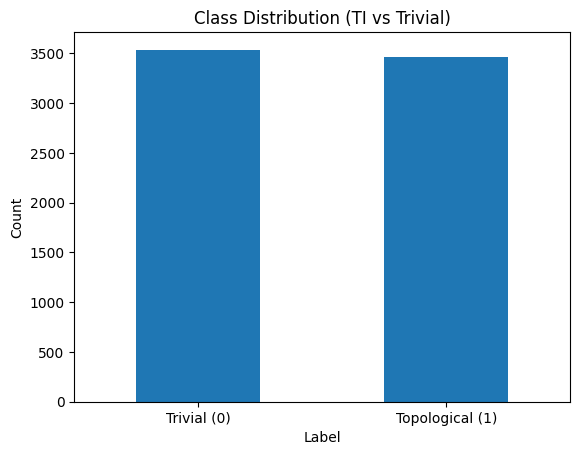

In [ ]:
#check class balance
# Count samples in each class
class_counts = df["label"].value_counts()

print("Number of samples per class:\n")
print(class_counts)

# Compute class ratio (percentage)
print("\nClass ratio (percentage):\n")
print(df["label"].value_counts(normalize=True) * 100)

# Check duplicates
duplicates = df.duplicated()

print("Number of duplicate rows:", duplicates.sum())

print("\nDuplicate rows:")
print(df[duplicates])

# Plot class distribution
class_counts.plot(kind="bar")

plt.title("Class Distribution (TI vs Trivial)")
plt.xlabel("Label")
plt.ylabel("Count")
plt.xticks([0, 1], ["Trivial (0)", "Topological (1)"], rotation=0)

plt.show()


Feature selection- structural, symmetry,electronic & atomic composition descriptors.

In [ ]:
# Feature selection
features = ["spacegroup_number","spacegroup", "number of atoms", "Band Gap",
            "a", "b", "c", "alpha", "beta", "gamma",
            "Z", "electronegativity"]

target = "label"

# Remove rows with missing values
df_model = df[features + [target]].dropna()

# Encode categorical columns automatically #spacegroup
for col in df_model.select_dtypes(include="object").columns:
    df_model[col] = df_model[col].astype("category").cat.codes

# Split features and target
X = df_model.drop(columns=[target])
y = df_model[target]

print("Cleaned data shape:", df_model.shape)
print("Final feature shape:", X.shape)
print("Target shape:", y.shape)

Cleaned data shape: (7000, 13)
Final feature shape: (7000, 12)
Target shape: (7000,)


splitting Cleaned data in train 70%,validation 15% and test 15%

In [ ]:
# First split: 70% train, 30% temp
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y,
    test_size=0.30,
    stratify=y,
    random_state=42
)

In [ ]:
# Split temp → 15% validation, 15% test
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp,
    test_size=0.50,  # 0.5 of 30% ≈ 15%
    stratify=y_temp,
    random_state=42
)

In [ ]:
print("Train:", X_train.shape)
print("Validation:", X_val.shape)
print("Test:", X_test.shape)
print("Train distribution:")
print(y_train.value_counts(normalize=True))

print("\nValidation distribution:")
print(y_val.value_counts(normalize=True))

print("\nTest distribution:")
print(y_test.value_counts(normalize=True))

Train: (4900, 12)
Validation: (1050, 12)
Test: (1050, 12)
Train distribution:
label
0    0.505102
1    0.494898
Name: proportion, dtype: float64

Validation distribution:
label
0    0.504762
1    0.495238
Name: proportion, dtype: float64

Test distribution:
label
0    0.505714
1    0.494286
Name: proportion, dtype: float64


Random Forest Model Training

In [ ]:
# Initialize Random Forest
rf = RandomForestClassifier(
    n_estimators=500,        # Number of trees
    max_depth=None,          # Allow trees to expand fully
    random_state=42,
    class_weight="balanced"  # Handle class imbalance
)
# Train the model
rf.fit(X_train, y_train)
print("Random Forest training complete.")

Random Forest training complete.


In [ ]:
# Evaluation function
def evaluate(model, X, y, name="Dataset"):
    y_pred = model.predict(X)
    y_prob = model.predict_proba(X)[:,1]  # Probability for positive class
    print(f"\n{name} Performance:")
    print(f"Accuracy: {accuracy_score(y, y_pred):.3f}")
    print(f"F1-score: {f1_score(y, y_pred):.3f}")
    print(f"ROC-AUC: {roc_auc_score(y, y_prob):.3f}")
    print(classification_report(y, y_pred, digits=3))

evaluate(rf, X_train, y_train, "Train")
evaluate(rf, X_val, y_val, "Validation")
evaluate(rf, X_test, y_test, "Test")


Train Performance:
Accuracy: 1.000
F1-score: 1.000
ROC-AUC: 1.000
              precision    recall  f1-score   support

           0      1.000     1.000     1.000      2475
           1      1.000     1.000     1.000      2425

    accuracy                          1.000      4900
   macro avg      1.000     1.000     1.000      4900
weighted avg      1.000     1.000     1.000      4900


Validation Performance:
Accuracy: 0.886
F1-score: 0.883
ROC-AUC: 0.944
              precision    recall  f1-score   support

           0      0.875     0.902     0.888       530
           1      0.897     0.869     0.883       520

    accuracy                          0.886      1050
   macro avg      0.886     0.886     0.886      1050
weighted avg      0.886     0.886     0.886      1050


Test Performance:
Accuracy: 0.858
F1-score: 0.854
ROC-AUC: 0.932
              precision    recall  f1-score   support

           0      0.847     0.878     0.862       531
           1      0.870     0.83

Interpreting the MOdel

In [ ]:
#Compute SHAP values using TreeExplainer
# Use the trained Random Forest model 'rf' and test data 'X_test'
explainer_rf = shap.TreeExplainer(rf)
shap_values_rf = explainer_rf(X_test)

# Select SHAP values for class 1 (Topological Insulator)
shap_class1 = shap_values_rf[:, :, 1]

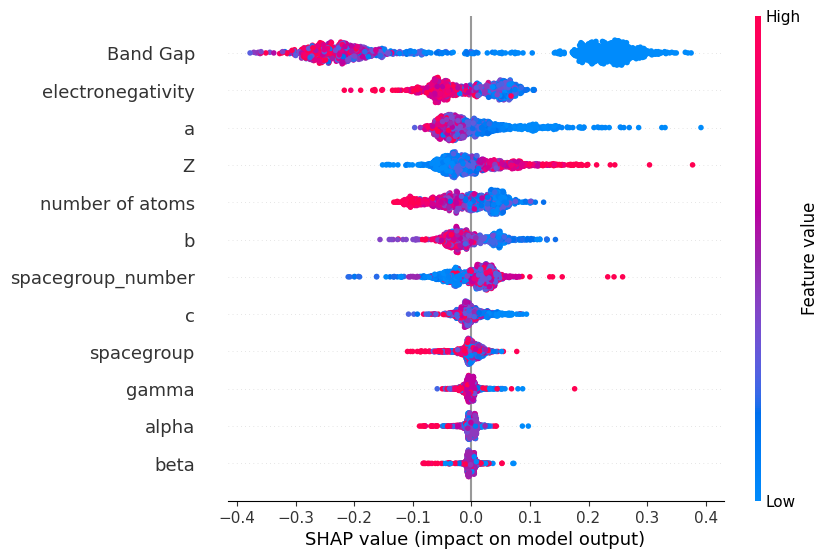

In [ ]:
# Global feature importance plots

# Beeswarm plot: shows the distribution of SHAP values for each feature
shap.plots.beeswarm(shap_class1, max_display=15)
plt.show()

The beewarm Plot

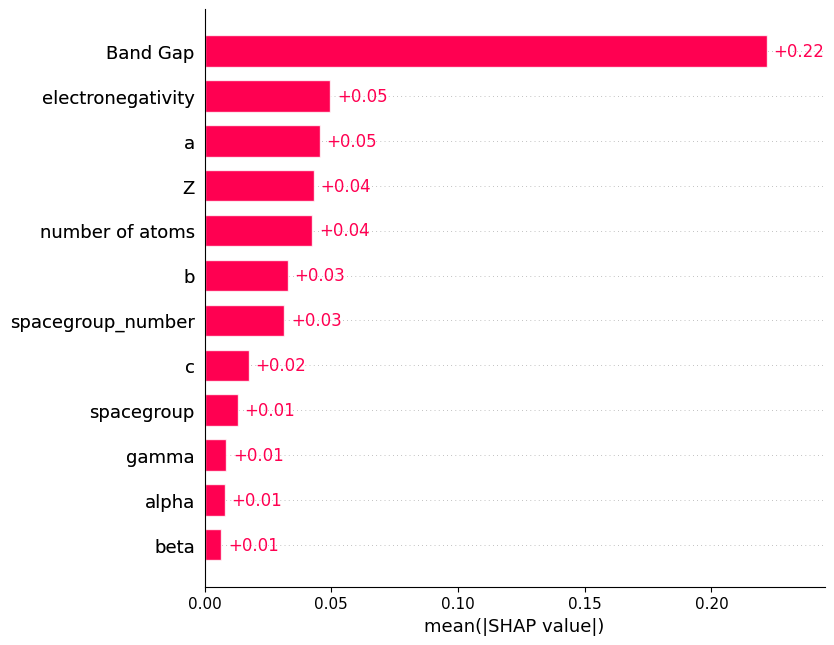

In [ ]:
# Bar plot: shows average absolute SHAP value for each feature
shap.plots.bar(shap_class1, max_display=15)
plt.show()


Waterfall plot for test sample 1:


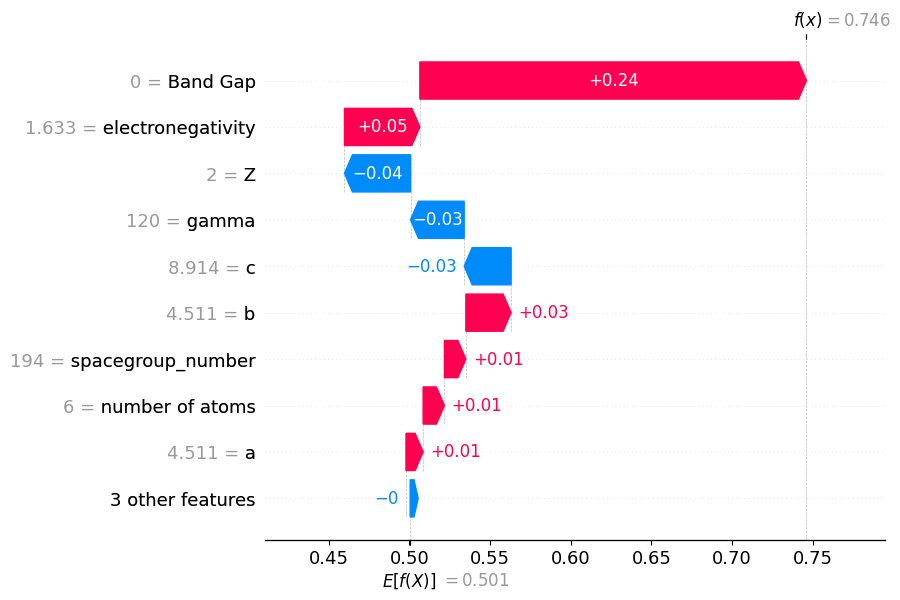


Waterfall plot for test sample 2:


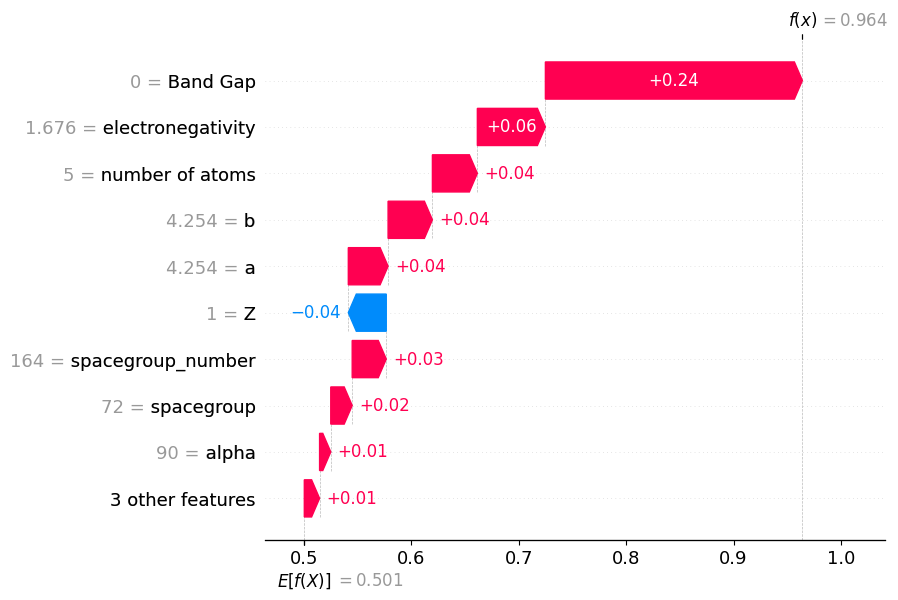


Waterfall plot for test sample 3:


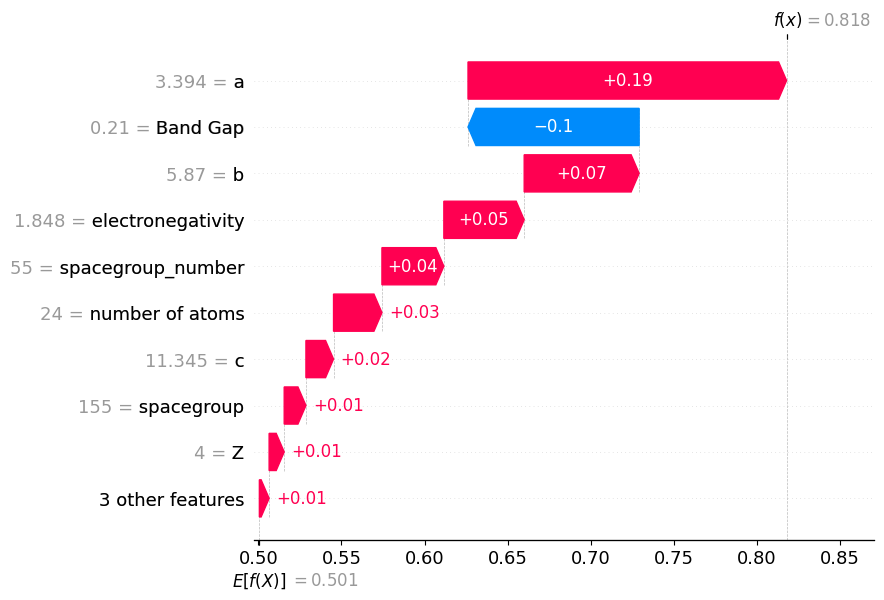

In [ ]:
# Local explanation (individual prediction)
# Waterfall plot for top 3 test samples (first 3 rows)
for i in range(3):
    print(f"\nWaterfall plot for test sample {i+1}:")
    shap.plots.waterfall(shap_class1[i])

XGBoost Model

In [ ]:
#model training
scale_pos_weight = y_train.value_counts()[0] / y_train.value_counts()[1]

xgb_model = xgb.XGBClassifier(
    n_estimators=500,
    max_depth=6,
    learning_rate=0.1,
    subsample=0.8,            # reduces overfitting slightly
    colsample_bytree=0.8,     # reduces feature correlation overfitting
    random_state=42,
    use_label_encoder=False,
    eval_metric="logloss",
    scale_pos_weight=scale_pos_weight
)

xgb_model.fit(X_train, y_train)
print("XGBoost training complete.")

/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [13:39:00] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


XGBoost training complete.


In [ ]:
# Define evaluation function
def evaluate(model, X_data, y_true, name="Dataset"):
    # Predict labels
    y_pred = model.predict(X_data)
    # Predict probability for TI class (class 1)
    y_prob = model.predict_proba(X_data)[:,1]

    print(f"\n{name} Performance:")
    print(f"Accuracy : {accuracy_score(y_true, y_pred):.3f}")
    print(f"F1-score : {f1_score(y_true, y_pred):.3f}")
    print(f"ROC-AUC  : {roc_auc_score(y_true, y_prob):.3f}")
    print(classification_report(y_true, y_pred, digits=3))

# Evaluate on each split
evaluate(xgb_model, X_train, y_train, "Train")
evaluate(xgb_model, X_val, y_val, "Validation")
evaluate(xgb_model, X_test, y_test, "Test")

NameError: name 'xgb_model' is not defined

In [ ]:
# Initialize TreeExplainer
explainer = shap.TreeExplainer(xgb_model)

# Compute SHAP values for test set
shap_values = explainer(X_test)  # Explanation object


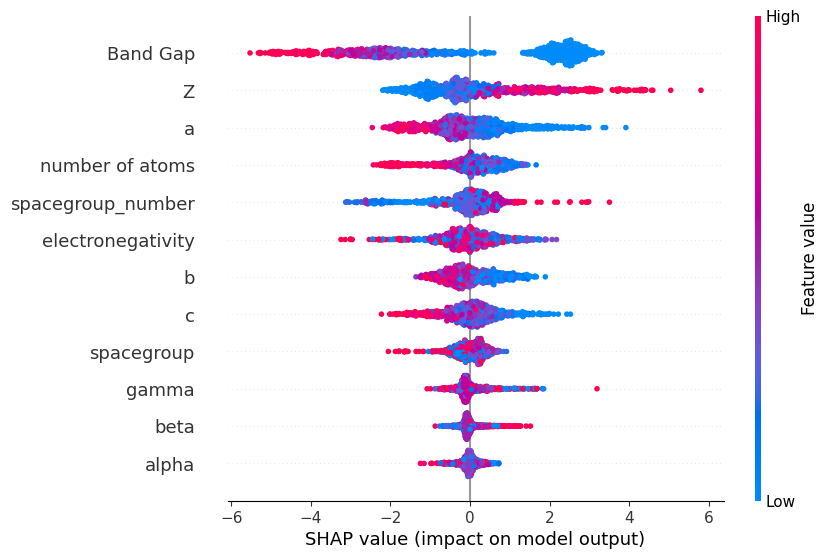

In [ ]:
# Global plots
# Beeswarm plot
shap.plots.beeswarm(shap_values, max_display=15)

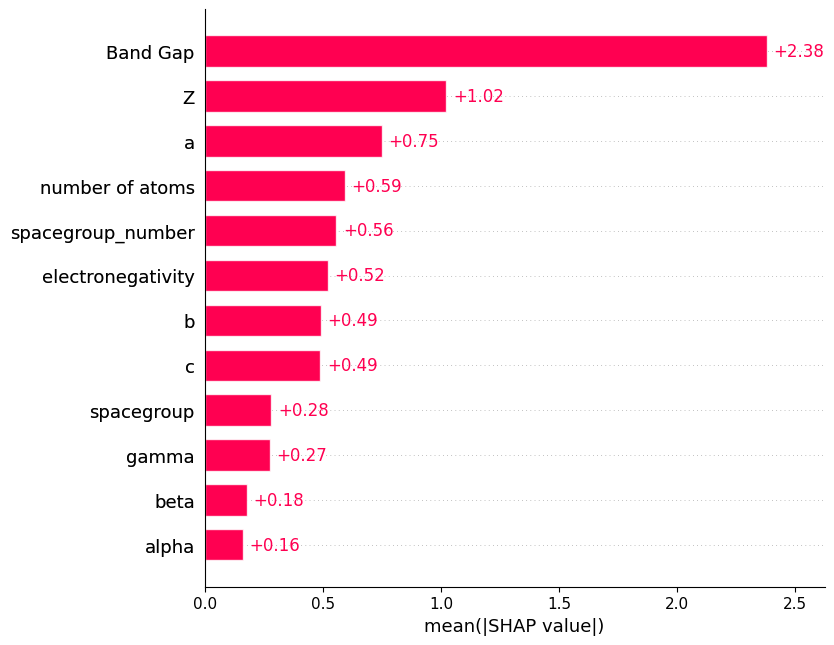

In [ ]:
# Bar plot (feature importance)
shap.plots.bar(shap_values, max_display=15)

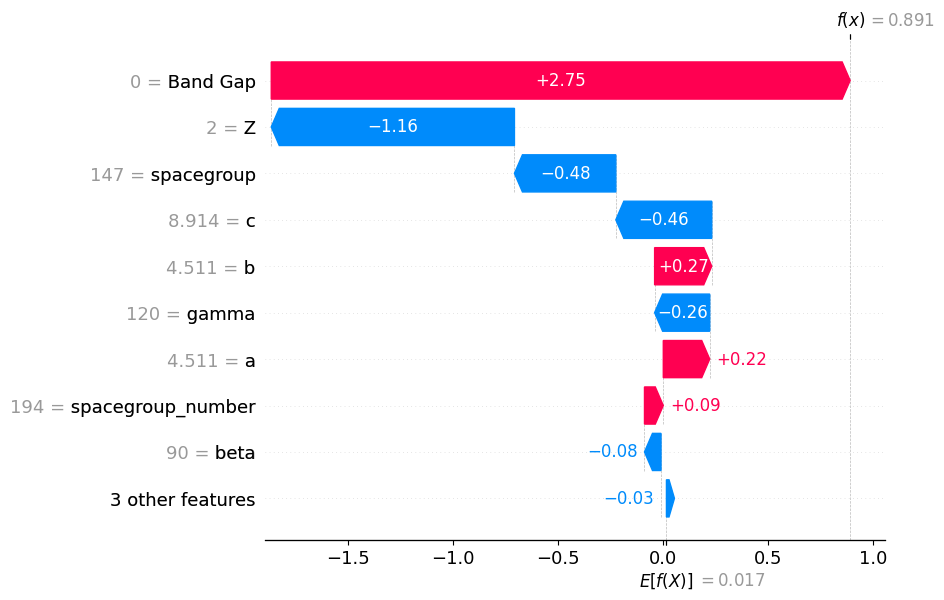

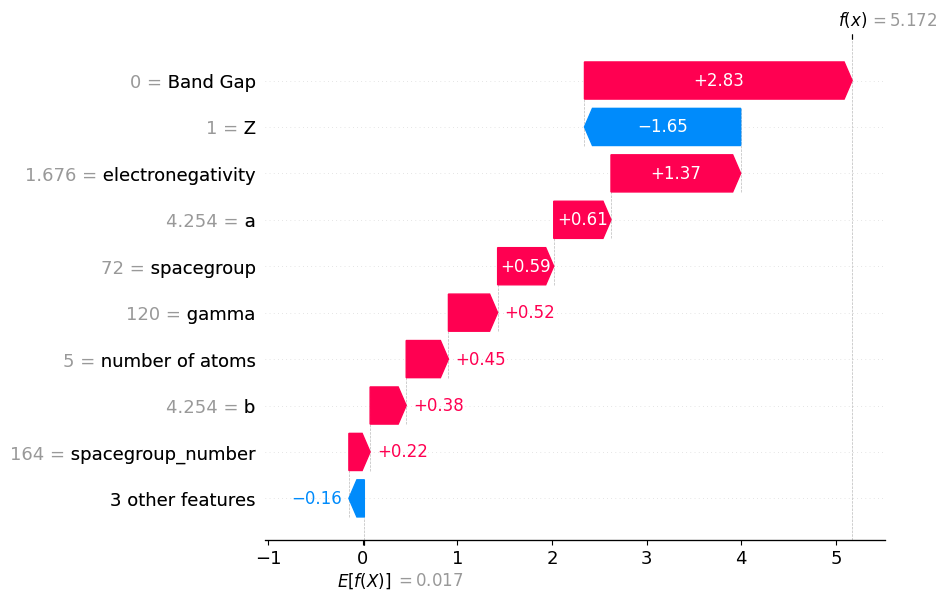

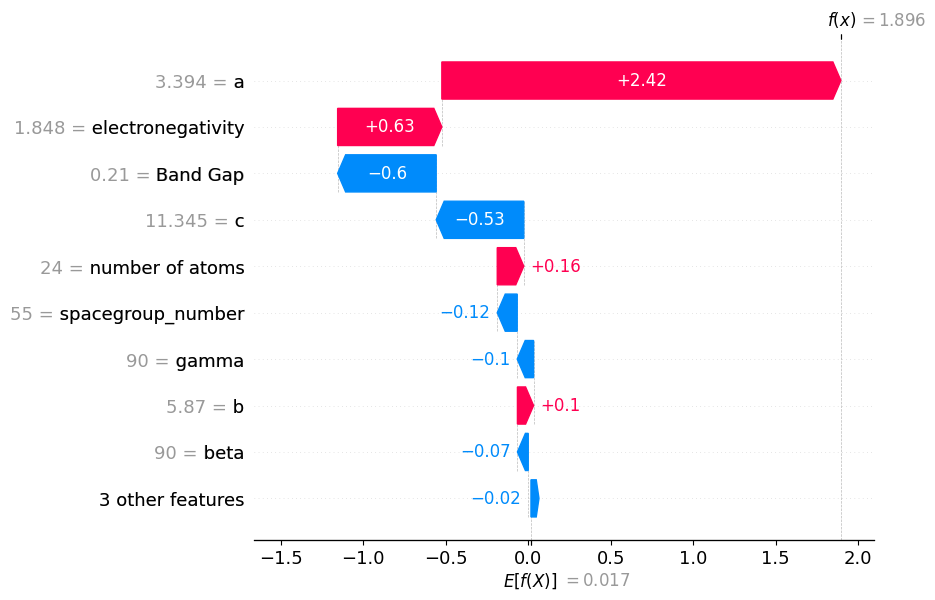

In [ ]:
# Local explanations (waterfall) for first 3 samples ---
for i in range(3):
    shap.plots.waterfall(shap_values[i])